In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
""" 
This implementation of random forest will use multi-label classification, 
this means it assumes multiple labels can exist in one audio.
"""

In [ ]:
from Data_n_Features_code import add_tonality_and_bpf_features
from pathlib import Path
import pandas as pd

#adding additional features to feature table
train_path = Path(r".\Data_v3\Bootstrapped_Audios\FeatureTable\train_df.csv")
test_path = Path(r".\Data_v3\Bootstrapped_Audios\FeatureTable\test_df.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

new_train_df = add_tonality_and_bpf_features(train_df)
new_test_df = add_tonality_and_bpf_features(test_df)

new_train_df.to_csv("train_df.csv", index = False)
new_test_df.to_csv("test_df.csv", index = False)


2026-07-23 08:26:44,453 - INFO - Adding tonality/BPF features [1/6300]: Data_v3\Bootstrapped_Audios\train\audio_1.wav
2026-07-23 08:26:46,189 - INFO - Adding tonality/BPF features [2/6300]: Data_v3\Bootstrapped_Audios\train\audio_2.wav
2026-07-23 08:26:46,215 - INFO - Adding tonality/BPF features [3/6300]: Data_v3\Bootstrapped_Audios\train\audio_3.wav
2026-07-23 08:26:46,242 - INFO - Adding tonality/BPF features [4/6300]: Data_v3\Bootstrapped_Audios\train\audio_4.wav
2026-07-23 08:26:46,280 - INFO - Adding tonality/BPF features [5/6300]: Data_v3\Bootstrapped_Audios\train\audio_5.wav
2026-07-23 08:26:46,304 - INFO - Adding tonality/BPF features [6/6300]: Data_v3\Bootstrapped_Audios\train\audio_6.wav
2026-07-23 08:26:46,342 - INFO - Adding tonality/BPF features [7/6300]: Data_v3\Bootstrapped_Audios\train\audio_7.wav
2026-07-23 08:26:46,380 - INFO - Adding tonality/BPF features [8/6300]: Data_v3\Bootstrapped_Audios\train\audio_8.wav
2026-07-23 08:26:46,418 - INFO - Adding tonality/BPF fea

Multi-label RF

In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import (
    accuracy_score, classification_report,
    multilabel_confusion_matrix, f1_score
)


train_p = Path(r".\Data_v3\Bootstrapped_Audios\FeatureTable\train_df.csv")
test_p = Path(r".\Data_v3\Bootstrapped_Audios\FeatureTable\test_df.csv")
train_df = pd.read_csv(train_p)
test_df = pd.read_csv(test_p)

label_cols = ["label_overlay_Airplanes", "label_overlay_Drones", "label_overlay_Explosion",
              "label_overlay_Gunshots", "label_overlay_Helicopter",
              "label_overlay_Land_Vehicles", "label_overlay_shortened_unlabeled"]
non_feature_cols = ["filepath", "label_base"] + label_cols
feature_cols = [c for c in train_df.columns if c not in non_feature_cols]

X_train = train_df[feature_cols]
y_train = train_df[label_cols]
X_test = test_df[feature_cols]
y_test = test_df[label_cols]

target_names = [c.replace("label_overlay_", "") for c in label_cols]

Cross Validation

In [7]:
clf = RandomForestClassifier(n_estimators=200, n_jobs=-1)


cv = MultilabelStratifiedKFold(n_splits=10, shuffle=True)

scoring = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]

cv_results = cross_validate(
    clf, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)

print("=== Cross-Validation Results (10-fold) ===")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:15s}: mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores, 3)}")


=== Cross-Validation Results (10-fold) ===
accuracy       : mean=0.8519  std=0.0281  folds=[0.84  0.889 0.857 0.825 0.876 0.861 0.88  0.859 0.844 0.788]
f1_macro       : mean=0.8754  std=0.0156  folds=[0.868 0.901 0.875 0.863 0.896 0.874 0.883 0.886 0.863 0.846]
precision_macro: mean=0.9351  std=0.0140  folds=[0.935 0.951 0.948 0.925 0.948 0.939 0.942 0.935 0.93  0.9  ]
recall_macro   : mean=0.8250  std=0.0181  folds=[0.812 0.856 0.815 0.812 0.85  0.819 0.833 0.843 0.806 0.804]


Test on Unseen


=== Final Held-Out Test ===
Test Subset Accuracy: 0.3600
                     precision    recall  f1-score   support

          Airplanes       0.93      0.63      0.75       349
             Drones       0.92      0.37      0.52       353
          Explosion       0.83      0.65      0.73       346
           Gunshots       0.86      0.64      0.73       337
         Helicopter       0.76      0.74      0.75       342
      Land_Vehicles       0.84      0.56      0.68       333
shortened_unlabeled       0.75      0.80      0.77       303

          micro avg       0.83      0.62      0.71      2363
          macro avg       0.84      0.63      0.70      2363
       weighted avg       0.84      0.62      0.70      2363
        samples avg       0.55      0.50      0.51      2363



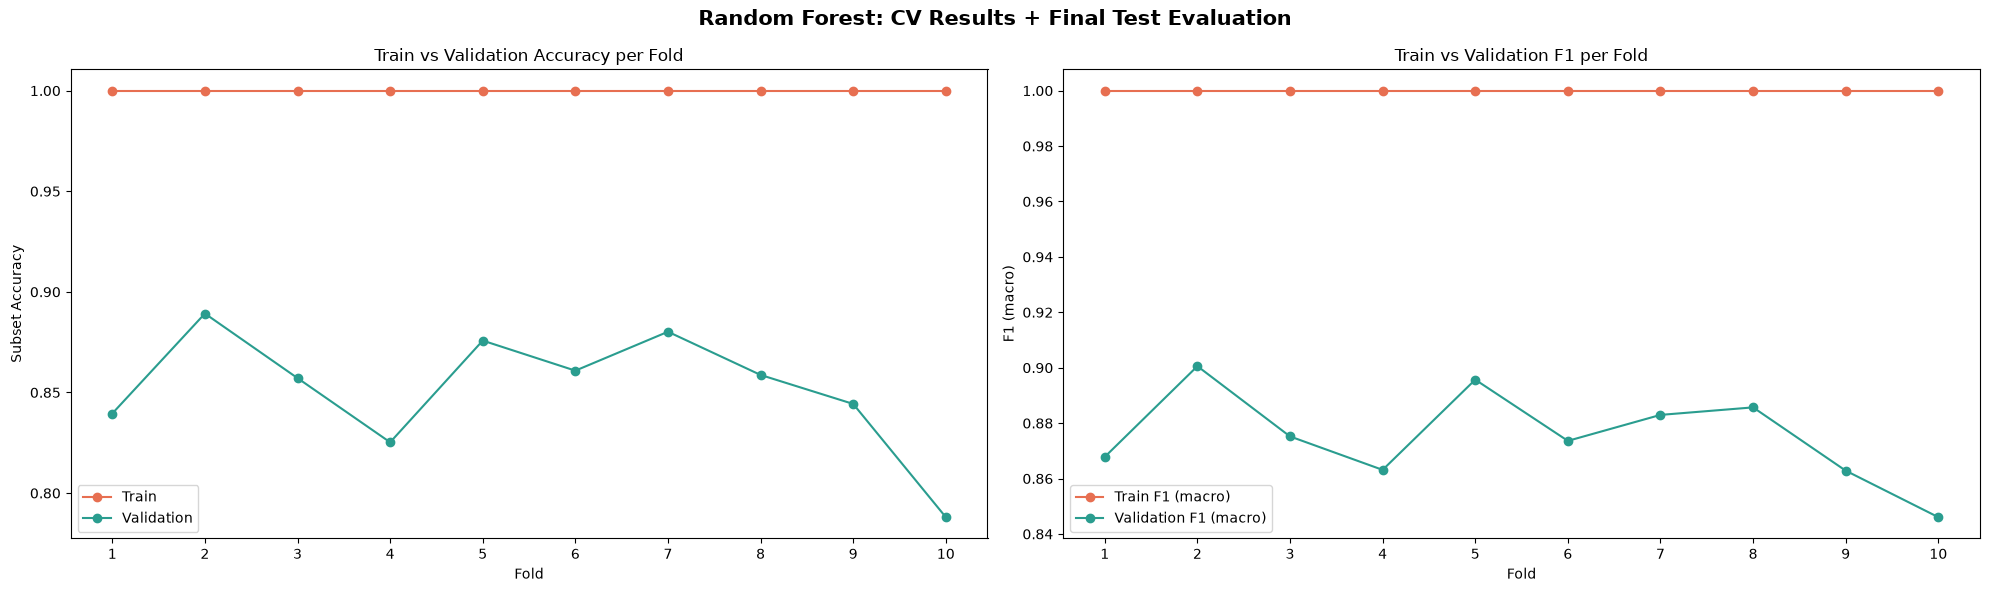

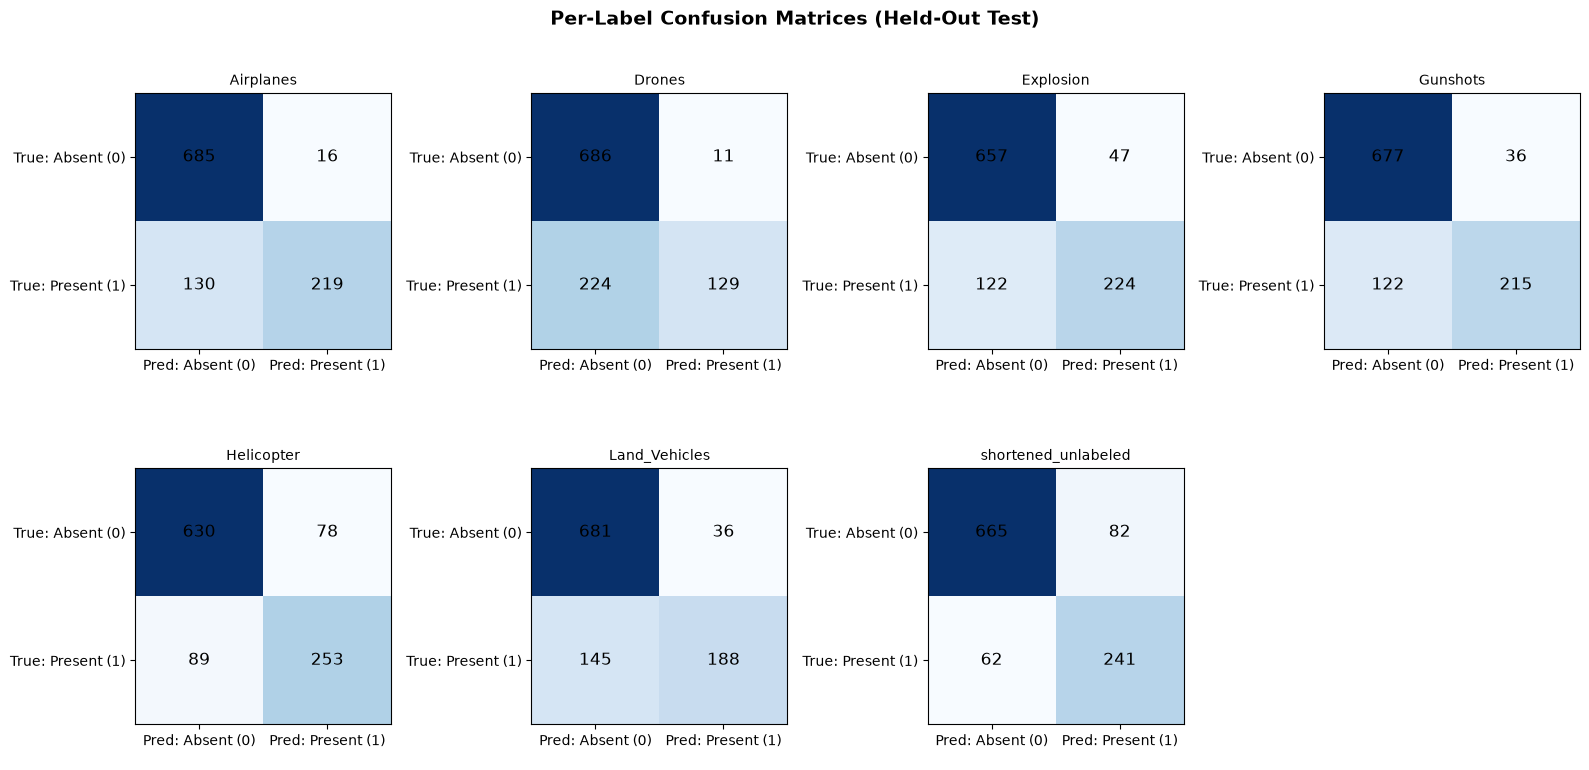

In [9]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)  # subset (exact-match) accuracy

print("\n=== Final Held-Out Test ===")
print(f"Test Subset Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

# --- Plot 1: Train vs validation accuracy per fold ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Random Forest: CV Results + Final Test Evaluation", fontsize=15, fontweight="bold")

ax = axes[0]
folds = np.arange(1, len(cv_results["test_accuracy"]) + 1)
ax.plot(folds, cv_results["train_accuracy"], marker="o", label="Train", color="#e76f51")
ax.plot(folds, cv_results["test_accuracy"], marker="o", label="Validation", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Subset Accuracy")
ax.set_title("Train vs Validation Accuracy per Fold")
ax.legend()

# Multi-label F1 per fold as a second view (subset accuracy alone can be misleading)
ax = axes[1]
ax.plot(folds, cv_results["train_f1_macro"], marker="o", label="Train F1 (macro)", color="#e76f51")
ax.plot(folds, cv_results["test_f1_macro"], marker="o", label="Validation F1 (macro)", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("F1 (macro)")
ax.set_title("Train vs Validation F1 per Fold")
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Multi-label confusion matrices (one per label, grid) ---
mcm = multilabel_confusion_matrix(y_test, y_pred)  # shape (n_labels, 2, 2)

n_labels = len(target_names)
ncols = 4
nrows = int(np.ceil(n_labels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, name in enumerate(target_names):
    ax = axes[i]
    cm = mcm[i]
    ax.imshow(cm, cmap="Blues")
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha="center", va="center",
                     color="black", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: Absent (0)", "Pred: Present (1)"])
    ax.set_yticklabels(["True: Absent (0)", "True: Present (1)"])
    ax.set_title(name, fontsize=10)
    ax.set_title(name, fontsize=10)

for j in range(n_labels, len(axes)):
    axes[j].axis("off")

fig.suptitle("Per-Label Confusion Matrices (Held-Out Test)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Feature Importance

In [10]:
def top_features_by_cumulative_importance(clf, feature_names, threshold=0.90):
    importances = clf.feature_importances_
    order = np.argsort(importances)[::-1]
    sorted_importances = importances[order]
    sorted_names = np.array(feature_names)[order]
    cumulative = np.cumsum(sorted_importances)
    n_features = np.searchsorted(cumulative, threshold) + 1
    return pd.DataFrame({
        "feature": sorted_names[:n_features],
        "importance": sorted_importances[:n_features],
        "cumulative": cumulative[:n_features]
    })

top_feats = top_features_by_cumulative_importance(clf, X_train.columns, threshold=0.90)
print("\n=== Top features (90% cumulative importance) ===")
print(top_feats)


=== Top features (90% cumulative importance) ===
               feature  importance  cumulative
0    temporal_centroid    0.036680    0.036680
1           mfcc_1_std    0.025763    0.062443
2           decay_time    0.019892    0.082335
3      band_high_ratio    0.019701    0.102036
4           mfcc_1_min    0.019350    0.121385
..                 ...         ...         ...
147         mfcc_9_std    0.002460    0.891775
148        mfcc_11_max    0.002442    0.894217
149      delta2_11_std    0.002437    0.896654
150         mfcc_9_max    0.002404    0.899058
151       delta_10_std    0.002381    0.901439

[152 rows x 3 columns]


Re-evaluating w/o Land Vehicles class

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import (
    accuracy_score, classification_report,
    multilabel_confusion_matrix, f1_score
)


train_p = Path(r".\Data_v3\Bootstrapped_Audios_No_Land_Vehicles\FeatureTable\train_df.csv")
test_p = Path(r".\Data_v3\Bootstrapped_Audios_No_Land_Vehicles\FeatureTable\test_df.csv")
train_df = pd.read_csv(train_p)
test_df = pd.read_csv(test_p)


label_cols = ["label_overlay_Airplanes", "label_overlay_Drones", "label_overlay_Explosion",
              "label_overlay_Gunshots", "label_overlay_Helicopter", "label_overlay_shortened_unlabeled"]
non_feature_cols = ["filepath", "label_base"] + label_cols
feature_cols = [c for c in train_df.columns if c not in non_feature_cols]

X_train = train_df[feature_cols]
y_train = train_df[label_cols]
X_test = test_df[feature_cols]
y_test = test_df[label_cols]

target_names = [c.replace("label_overlay_", "") for c in label_cols]

Cross Validation

In [2]:
clf = RandomForestClassifier(n_estimators=200, n_jobs=-1)


cv = MultilabelStratifiedKFold(n_splits=10, shuffle=True)

scoring = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]

cv_results = cross_validate(
    clf, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)

print("=== Cross-Validation Results (10-fold) ===")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:15s}: mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores, 3)}")


=== Cross-Validation Results (10-fold) ===
accuracy       : mean=0.5055  std=0.0578  folds=[0.372 0.512 0.522 0.576 0.509 0.579 0.48  0.492 0.463 0.552]
f1_macro       : mean=0.8611  std=0.0212  folds=[0.82  0.858 0.868 0.868 0.887 0.889 0.848 0.849 0.84  0.883]
precision_macro: mean=0.8266  std=0.0171  folds=[0.794 0.841 0.817 0.823 0.846 0.853 0.814 0.823 0.814 0.84 ]
recall_macro   : mean=0.9000  std=0.0298  folds=[0.85  0.876 0.925 0.92  0.934 0.931 0.885 0.88  0.868 0.932]


Test on Unseen


=== Final Held-Out Test ===
Test Subset Accuracy: 0.4400
                     precision    recall  f1-score   support

          Airplanes       0.85      0.90      0.88       240
             Drones       0.81      0.76      0.78       225
          Explosion       0.78      0.91      0.84       242
           Gunshots       0.77      0.84      0.80       225
         Helicopter       0.88      0.90      0.89       239
shortened_unlabeled       0.77      0.90      0.83       230

          micro avg       0.81      0.87      0.84      1401
          macro avg       0.81      0.87      0.84      1401
       weighted avg       0.81      0.87      0.84      1401
        samples avg       0.75      0.80      0.75      1401



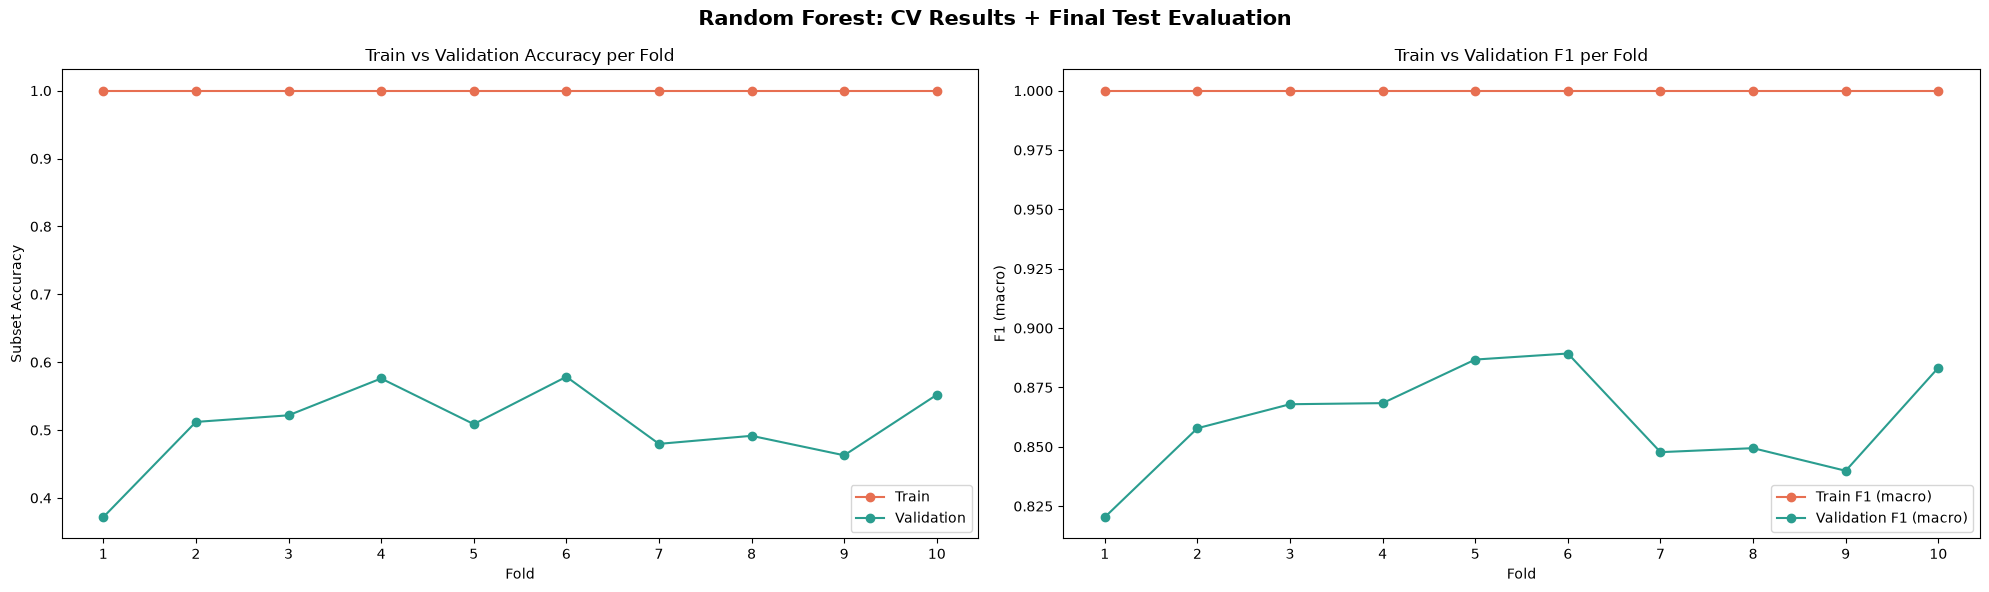

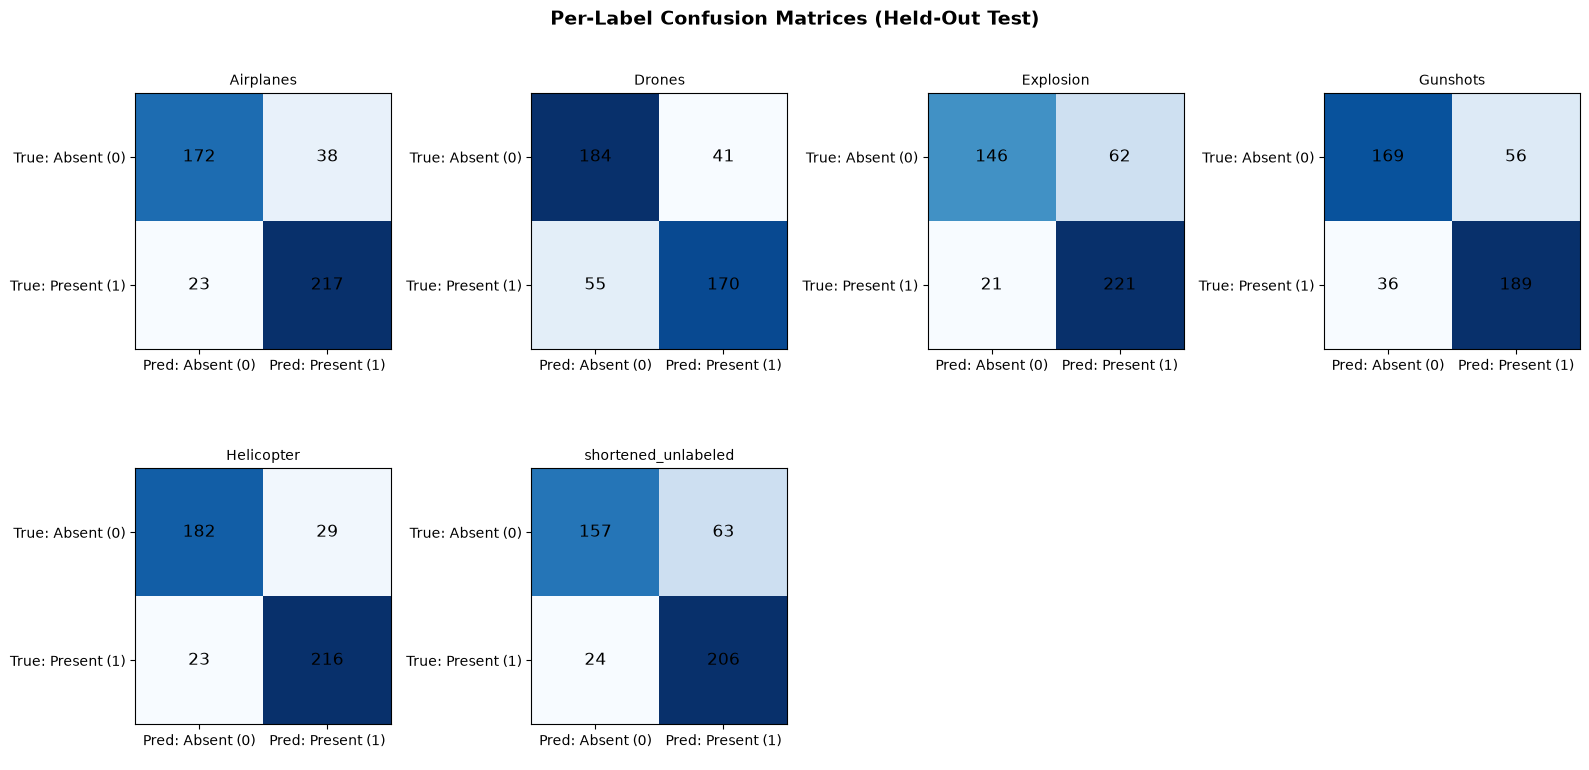

In [3]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)  # subset (exact-match) accuracy

print("\n=== Final Held-Out Test ===")
print(f"Test Subset Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

# --- Plot 1: Train vs validation accuracy per fold ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("Random Forest: CV Results + Final Test Evaluation", fontsize=15, fontweight="bold")

ax = axes[0]
folds = np.arange(1, len(cv_results["test_accuracy"]) + 1)
ax.plot(folds, cv_results["train_accuracy"], marker="o", label="Train", color="#e76f51")
ax.plot(folds, cv_results["test_accuracy"], marker="o", label="Validation", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Subset Accuracy")
ax.set_title("Train vs Validation Accuracy per Fold")
ax.legend()

# Multi-label F1 per fold as a second view (subset accuracy alone can be misleading)
ax = axes[1]
ax.plot(folds, cv_results["train_f1_macro"], marker="o", label="Train F1 (macro)", color="#e76f51")
ax.plot(folds, cv_results["test_f1_macro"], marker="o", label="Validation F1 (macro)", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("F1 (macro)")
ax.set_title("Train vs Validation F1 per Fold")
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Multi-label confusion matrices (one per label, grid) ---
mcm = multilabel_confusion_matrix(y_test, y_pred)  # shape (n_labels, 2, 2)

n_labels = len(target_names)
ncols = 4
nrows = int(np.ceil(n_labels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, name in enumerate(target_names):
    ax = axes[i]
    cm = mcm[i]
    ax.imshow(cm, cmap="Blues")
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha="center", va="center",
                     color="black", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: Absent (0)", "Pred: Present (1)"])
    ax.set_yticklabels(["True: Absent (0)", "True: Present (1)"])
    ax.set_title(name, fontsize=10)
    ax.set_title(name, fontsize=10)

for j in range(n_labels, len(axes)):
    axes[j].axis("off")

fig.suptitle("Per-Label Confusion Matrices (Held-Out Test)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Feature Importance

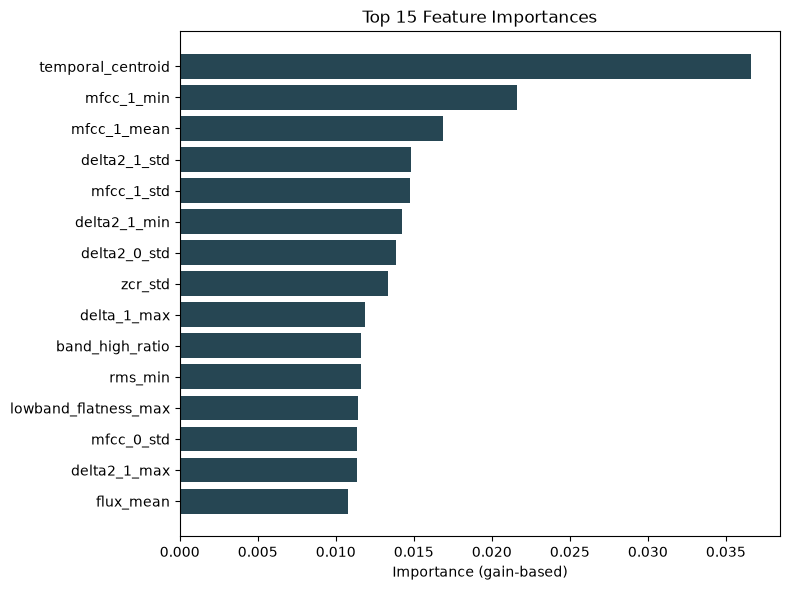

In [4]:
feature_names = np.array(X_train.columns)
importances = clf.feature_importances_
order = np.argsort(importances)[-15:]   # top 15 features

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(order)), importances[order], color="#264653")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(feature_names[order])
ax.set_xlabel("Importance (gain-based)")
ax.set_title("Top 15 Feature Importances")
plt.tight_layout()
plt.show()